# Task 2: Petri Dish Detection and Extraction

In Computer Vision, Region of Interest (ROI) extraction involves identifying and isolating specific parts of an image deemed important for further analysis. This process allows focused processing on these selected areas, often enhancing efficiency and accuracy.


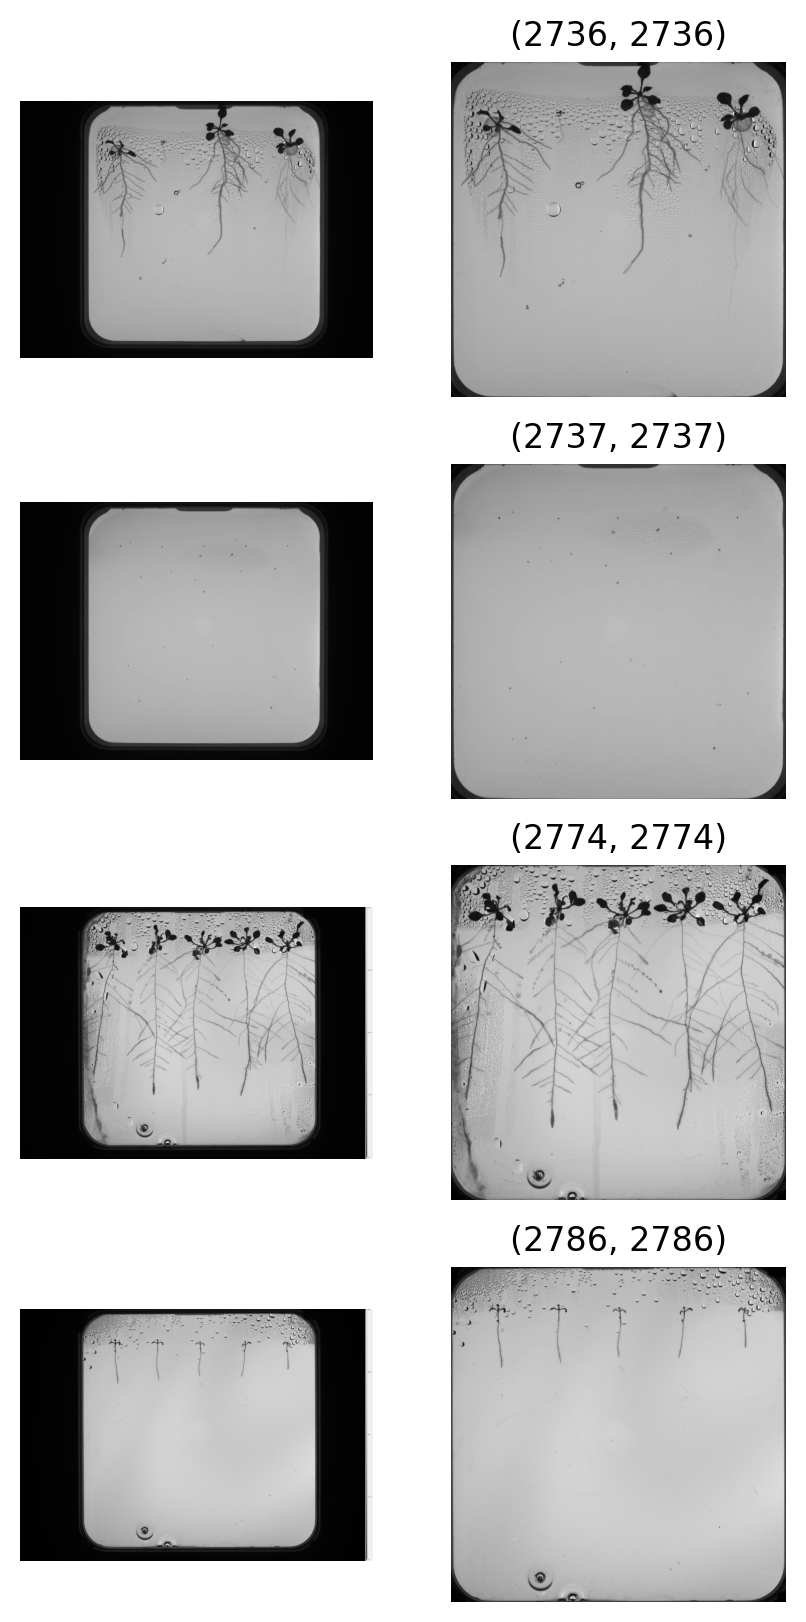

In this project, the ROI is the Petri Dish. Your task is to write a Python code using traditional computer vision methods that crop the Petri dish from any raw image from the datasets Y2B_23 and Y2B_24. Note that these datasets are slightly different. For example, Y2B_23 images contain a white legend on the right edge, while Y2B_24 images do not. Also, Petri Dishes are different. In the following tasks, you will use the Petri Dish extraction code so that you don’t have to process outside the Petri Dish where no plant is present. This will save you time and compute. But more importantly, the model will learn better. You can achieve this task with deep learning, but that would be overkill; therefore, using traditional CV methods is a requirement.

Please assume that the Petri dish is a square, ignoring corner curvature, with its edges parallel to the image borders. However, its location can change from one image to the other. The cropped image must be a square.
Deliverables

The code (task_2.ipynb), with comments/docstrings explaining each step. The notebook should display the output of the code on two random images from Y2B_23 and two random images from Y2B_24 (Figure 2.1).

### Client Requirements

Your code should rely on traditional computer vision methods. In other words, do not use an ML/DL model.

Detected Petri dish edges must be within ± 30 pixels of the actual Petri dish edges.

The code should be general enough to work on all the dataset images (Y2B_23 and Y2B_24).

The output of the code must be a square.

An image similar to Figure 2.1 is shown in task_2.ipynb.

### ILO mapping

ILO 6.4B (3 points), no partial points. If you fail to meet the requirements or if you have evidencing issues, you will receive 0 from ILO 6.4B.
Evidencing

In your learning log section C, under ILO 6.4B, provide a link to task_2.ipynb and describe how you have solved this task in a few sentences.

In [11]:
# Import the libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import skimage

In [87]:
def extract_petri_dish(image):
    """
    Extracts a square region containing the Petri dish from the input image.
    
    Args:
        image: Input grayscale image
        
    Returns:
        Cropped square image containing the Petri dish
    """
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Use Otsu's thresholding to separate dish from background
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Find the largest contour (should be the Petri dish)
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get bounding rectangle
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Calculate the size of the square crop (use larger dimension)
    size = max(w, h)
    
    # Calculate new coordinates to center the dish
    center_x = x + w//2
    center_y = y + h//2
    
    # Calculate crop coordinates
    x1 = max(0, center_x - size//2)
    y1 = max(0, center_y - size//2)
    x2 = min(image.shape[1], x1 + size)
    y2 = min(image.shape[0], y1 + size)
    
    # Crop the image
    cropped = image[y1:y2, x1:x2]
    
    return cropped

In [88]:
def display_results(original, cropped, title):
    """Helper function to display original and cropped images side by side"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    ax1.imshow(original, cmap='gray')
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    ax2.imshow(cropped, cmap='gray')
    ax2.set_title('Cropped Petri Dish')
    ax2.axis('off')
    
    plt.suptitle(title)
    plt.show()

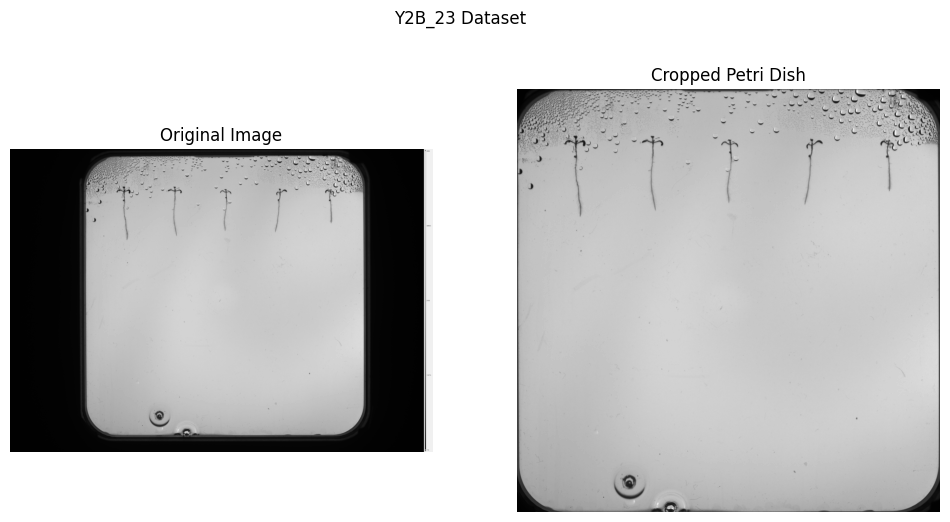

In [89]:
# Example usage:
# Load and process images from both datasets
img_y2b23 = cv2.imread('images/img1.png', 0)
cropped_y2b23 = extract_petri_dish(img_y2b23)
display_results(img_y2b23, cropped_y2b23, 'Y2B_23 Dataset')

# img_y2b24 = cv2.imread('path_to_Y2B_24_image.png', 0)
# cropped_y2b24 = extract_petri_dish(img_y2b24)
# display_results(img_y2b24, cropped_y2b24, 'Y2B_24 Dataset')